# PKTD3-TD: Real-Time Checkpoint & Actor Saturation Monitor

This independent diagnostic notebook allows you to monitor training checkpoints in real time as they land on **Google Drive** without interrupting or touching the running `train_colab.ipynb` training kernel.

### How to Use:
1. Open this notebook in a **separate Colab tab** while `train_colab.ipynb` is running.
2. Mount the same Google Drive.
3. Run the diff check cell at any time (e.g. after episode 500, 1000, 1500, etc.).
4. Verify that `mean_abs_diff > 0.01` and the actor is actively learning rather than frozen.

In [22]:
# Step 1: Mount Google Drive to access ongoing checkpoints
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# Step 2: Clone repository and ensure package source is on sys.path
import os, sys

repo_dir = "/content/uav_trajectory_rl"
if not os.path.exists(repo_dir):
    !git clone https://github.com/Krishna200608/uav_trajectory_rl.git {repo_dir}
else:
    %cd {repo_dir}
    !git pull

%cd {repo_dir}
!pip install -e . --quiet

# Direct import path fallback
src_path = os.path.join(repo_dir, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Ready! Module search path includes:", src_path)

/content/uav_trajectory_rl
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 2), reused 19 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (19/19), 37.22 MiB | 14.82 MiB/s, done.
From https://github.com/Krishna200608/uav_trajectory_rl
   62d0ade..9544ca6  main       -> origin/main
Updating 62d0ade..9544ca6
Fast-forward
 checkpoints/run2/episode_rewards.npy       | Bin 0 -> 24128 bytes
 checkpoints/run2/td3_agent_ep1000.pt       | Bin 0 -> 3564085 bytes
 checkpoints/run2/td3_agent_ep1500.pt       | Bin 0 -> 3564085 bytes
 checkpoints/run2/td3_agent_ep2000.pt       | Bin 0 -> 3564085 bytes
 checkpoints/run2/td3_agent_ep2500.pt       | Bin 0 -> 3564085 bytes
 checkpoints/run2/td3_agent_ep3000.pt       | Bin 0 -> 3564085 bytes
 checkpoints/run2/td3_agent_ep3500.pt       | Bin 0 -> 3564085 bytes
 checkpoints/run2/td3_agent_ep4000.pt       | Bin 0 -> 3564085 bytes
 checkpoint

In [24]:
# Step 3: Set the Drive checkpoint path where training is actively writing
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/Uav_trajectory_rl/PKTD3_TD_Checkpoints/run2"

if not os.path.exists(CHECKPOINT_DIR):
    print(f"Directory {CHECKPOINT_DIR} not found. Checking alternate locations...")
    alt_dir = "/content/drive/MyDrive/Uav_trajectory_rl/PKTD3_TD_Checkpoints/run1"
    if os.path.exists(alt_dir):
        print(f"Found run1 at: {alt_dir}")

# List existing checkpoints
!ls -la "{CHECKPOINT_DIR}"

total 45276
-rw------- 1 root root   24128 Aug 28 08:27 episode_rewards.npy
-rw------- 1 root root 3564085 Aug 28 06:36 td3_agent_ep1000.pt
-rw------- 1 root root 3564085 Aug 28 06:47 td3_agent_ep1500.pt
-rw------- 1 root root 3564085 Aug 28 06:58 td3_agent_ep2000.pt
-rw------- 1 root root 3564085 Aug 28 07:09 td3_agent_ep2500.pt
-rw------- 1 root root 3564085 Aug 28 07:20 td3_agent_ep3000.pt
-rw------- 1 root root 3564085 Aug 28 07:31 td3_agent_ep3500.pt
-rw------- 1 root root 3564085 Aug 28 07:42 td3_agent_ep4000.pt
-rw------- 1 root root 3564085 Aug 28 07:53 td3_agent_ep4500.pt
-rw------- 1 root root 3564085 Aug 28 08:05 td3_agent_ep5000.pt
-rw------- 1 root root 3563989 Aug 28 06:24 td3_agent_ep500.pt
-rw------- 1 root root 3564085 Aug 28 08:16 td3_agent_ep5500.pt
-rw------- 1 root root 3564085 Aug 28 08:27 td3_agent_ep6000.pt
-rw------- 1 root root 3563989 Aug 28 08:27 td3_agent_final.pt


In [25]:
# Step 4: Evaluate actor outputs on fixed test states across checkpoints
import os, sys

# Ensure package source is unconditionally resolvable
for p in ["/content/uav_trajectory_rl/src", "src", "."]:
    abs_p = os.path.abspath(p)
    if os.path.exists(abs_p) and abs_p not in sys.path:
        sys.path.insert(0, abs_p)

import glob, re, torch
import numpy as np
from uav_trajectory_rl.td3_networks import Actor

# Find all checkpoints currently on disk, sorted by episode number
ckpt_files = glob.glob(f"{CHECKPOINT_DIR}/td3_agent_ep*.pt")
episodes = sorted(int(re.search(r"ep(\d+)", f).group(1)) for f in ckpt_files)
print("Checkpoints found so far:", episodes)

if not episodes:
    print("No episode checkpoints found yet. Re-run this cell once the first checkpoint (e.g. ep500) has saved.")
else:
    # Fixed test states -- same seed every time you run this, so results are comparable
    # across different points in training and across different runs
    rng = np.random.default_rng(999)
    test_states = rng.uniform(-1.0, 1.0, size=(8, 26)).astype(np.float32)  # state_dim=26 for K=10
    states_t = torch.as_tensor(test_states)

    results = {}
    for ep in episodes:
        ckpt = torch.load(f"{CHECKPOINT_DIR}/td3_agent_ep{ep}.pt", map_location="cpu", weights_only=True)
        actor = Actor(state_dim=26, action_dim=3, max_action=1.0)
        actor.load_state_dict(ckpt["actor"])
        actor.eval()
        with torch.no_grad():
            out = actor(states_t).numpy()
        results[ep] = out
        print(f"\n--- ep{ep} (total_updates={ckpt['total_updates']}) ---")
        print(out.round(4))

    if len(episodes) > 1:
        print("\n=== Mean abs change between consecutive checkpoints ===")
        for a, b in zip(episodes, episodes[1:]):
            diff = np.abs(results[b] - results[a]).mean()
            saturated_frac = (np.abs(results[b]) > 0.999).mean()
            print(f"ep{a} -> ep{b}: mean_abs_diff={diff:.6f}, frac_outputs_saturated(|x|>0.999)={saturated_frac:.2f}")

    print("\n=== INTERPRETATION ===")
    if len(episodes) < 2:
        sat_frac = (np.abs(results[episodes[0]]) > 0.999).mean()
        print(f"Found 1 checkpoint (ep{episodes[0]}). Output saturation fraction (|x|>0.999): {sat_frac:.2f}")
        print("Checkpoint-to-checkpoint diff requires at least 2 checkpoints. Re-run this cell once ep1000 arrives on Drive!")
    else:
        last_diff = np.abs(results[episodes[-1]] - results[episodes[-2]]).mean()
        if last_diff < 1e-4:
            print("WARNING: latest two checkpoints are near-identical -- actor may be frozen again. Consider stopping and investigating before letting the full run finish.")
        else:
            print(f"OK: actor output is still changing between checkpoints (mean diff = {last_diff:.4f}) -- training appears active, not frozen.")

Checkpoints found so far: [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]

--- ep500 (total_updates=77137) ---
[[-0.6097  0.3129 -0.9815]
 [-0.9955 -1.      0.9162]
 [ 1.     -1.     -0.8555]
 [-1.     -0.8604 -0.1633]
 [ 0.9985 -0.7357  0.2207]
 [-1.     -0.991  -0.9996]
 [-1.     -1.      0.8474]
 [-1.      0.9709  0.9985]]

--- ep1000 (total_updates=177137) ---
[[ 1.      0.8041 -0.8107]
 [ 0.9998  0.9955  1.    ]
 [ 0.9938 -0.9992  0.8383]
 [-0.3083  0.511  -1.    ]
 [-1.      0.3149 -0.913 ]
 [-1.     -0.9979 -0.9986]
 [-1.     -0.9991 -0.8368]
 [-1.      0.8293 -0.8681]]

--- ep1500 (total_updates=277137) ---
[[-1.      0.9998  0.9988]
 [-1.      1.      1.    ]
 [-1.     -0.6499  1.    ]
 [-1.      0.9996  0.9211]
 [-1.     -0.2023 -1.    ]
 [-1.      0.9886 -1.    ]
 [-1.     -0.9997 -0.4679]
 [-1.      0.9957 -0.9982]]

--- ep2000 (total_updates=377137) ---
[[-1.      1.      0.9957]
 [-1.      1.      0.8647]
 [-1.      0.9998  1.    ]
 [-1.      1.   

TRAINING PROGRESS: [██████████████████████████████] 100.0% (6000/6000 eps)
  Pace: 11.1 min per 500 episodes (0.75 ep/s)
  Time Remaining (ETA): ~0.0 minutes (0.00 hours)
  Estimated Completion: 08:33 AM (2026-08-28)

Live Rewards: 6000 episodes logged.
  Current Reward: -30.56
  Rolling Avg (last 50): -86.84


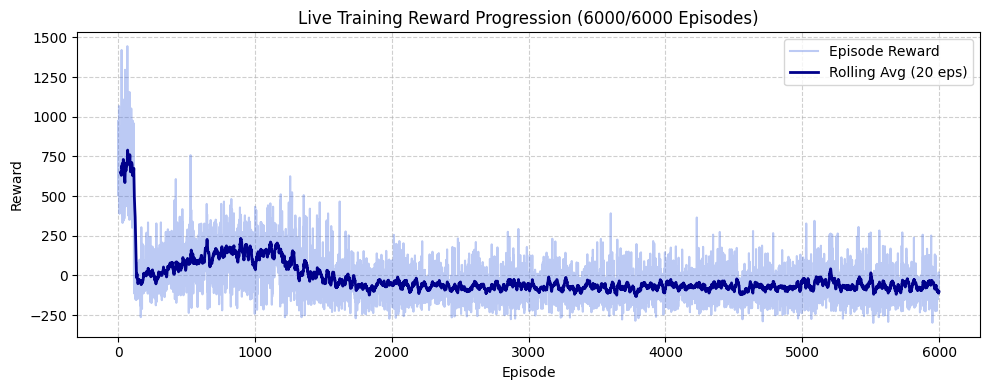

In [26]:
# Step 5: Live Training Progress, Time Remaining & Visual Reward Tracker
# Run this cell at any time while train_colab.ipynb is executing in your other tab!
import glob, os, re, time
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

TOTAL_EPISODES = 6000
CHECKPOINT_EVERY = 500

# 1. Discover all checkpoints on Google Drive
ckpt_files = sorted(
    glob.glob(f"{CHECKPOINT_DIR}/td3_agent_ep*.pt"),
    key=lambda f: int(re.search(r"ep(\d+)", f).group(1)) if re.search(r"ep(\d+)", f) else 0
)

if not ckpt_files:
    print(f"Waiting for checkpoints in {CHECKPOINT_DIR}...")
else:
    episodes = [int(re.search(r"ep(\d+)", f).group(1)) for f in ckpt_files]
    latest_ep = max(episodes)
    pct = (latest_ep / TOTAL_EPISODES) * 100.0

    # Visual ASCII/Unicode progress bar
    bar_width = 30
    filled = int(bar_width * (latest_ep / TOTAL_EPISODES))
    bar = "█" * filled + "░" * (bar_width - filled)

    # 2. Timing & ETA calculation from file modification timestamps
    mtimes = [os.path.getmtime(f) for f in ckpt_files]
    time_str = ""
    if len(mtimes) >= 2:
        total_ckpt_time_sec = mtimes[-1] - mtimes[0]
        completed_delta_eps = episodes[-1] - episodes[0]
        if completed_delta_eps > 0:
            sec_per_ep = total_ckpt_time_sec / completed_delta_eps
            sec_per_ckpt = sec_per_ep * CHECKPOINT_EVERY
            remaining_eps = TOTAL_EPISODES - latest_ep
            remaining_sec = remaining_eps * sec_per_ep
            eta_time = datetime.now() + timedelta(seconds=remaining_sec)

            time_str = (
                f"  Pace: {sec_per_ckpt / 60:.1f} min per {CHECKPOINT_EVERY} episodes ({1.0 / sec_per_ep:.2f} ep/s)\n"
                f"  Time Remaining (ETA): ~{remaining_sec / 60:.1f} minutes ({remaining_sec / 3600:.2f} hours)\n"
                f"  Estimated Completion: {eta_time.strftime('%I:%M %p (%Y-%m-%d)')}"
            )
    else:
        time_str = "  Pace: Calculating (requires 2+ checkpoints saved on Drive)..."

    print("=" * 65)
    print(f"TRAINING PROGRESS: [{bar}] {pct:.1f}% ({latest_ep}/{TOTAL_EPISODES} eps)")
    print("=" * 65)
    if time_str:
        print(time_str)

    # 3. Live reward curve visualization if episode_rewards.npy exists
    rewards_path = os.path.join(CHECKPOINT_DIR, "episode_rewards.npy")
    if os.path.exists(rewards_path):
        rewards = np.load(rewards_path)
        print(f"\nLive Rewards: {len(rewards)} episodes logged.")
        print(f"  Current Reward: {rewards[-1]:.2f}")
        print(f"  Rolling Avg (last 50): {np.mean(rewards[-50:]):.2f}")

        plt.figure(figsize=(10, 4))
        plt.plot(rewards, alpha=0.35, color="royalblue", label="Episode Reward")
        if len(rewards) >= 20:
            rolling_avg = np.convolve(rewards, np.ones(20)/20, mode="valid")
            plt.plot(range(19, len(rewards)), rolling_avg, color="darkblue", lw=2, label="Rolling Avg (20 eps)")
        plt.title(f"Live Training Reward Progression ({len(rewards)}/{TOTAL_EPISODES} Episodes)")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\n(Intermediate episode_rewards.npy will display once generated on Drive)")
